In [11]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from selfmixed_model import train, infer
from segysak.segy import segy_loader

In [12]:
LR_MODEL = 1e-3
N_EPOCH = 10000
IT_MODEL = 1
DECAY_INTERVAL = int(N_EPOCH / 8)

In [13]:
print(torch.cuda.is_available())  # Should output: True
print(torch.version.cuda)         # Should output: 11.8   

True
11.8


In [14]:
FILE_NAME = "FORGE_78-32_iDASv3-P11_UTC190423213209"
P_ARRIVAL = 1484
N_SAMPLE = 1024
N_TRACE = 256
segydata = segy_loader(f"{FILE_NAME}.sgy")

C:\Users\Long\AppData\Local\Temp\ipykernel_5884\2990813522.py:5: DeprecationWarning: segy_loader will be removed in v0.6, please use the Xarray engine ds = xr.open_dataset(segy_file) method instead.
  segydata = segy_loader(f"{FILE_NAME}.sgy")


Couldn't determine geometry, will load traces as flat 2D.


Converting SEGY: 100%|██████████| 1.28k/1.28k [00:00<00:00, 1.28k traces/s]


In [15]:
data = np.zeros((1280, 30000))
data = segydata.data
y = data[200:200+N_TRACE,P_ARRIVAL-20:P_ARRIVAL+N_SAMPLE-20].transpose()
y = np.array(y)
print(y.shape)

(1024, 256)


C:\Users\Long\AppData\Local\Temp\ipykernel_5884\1972575771.py:3: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  v = np.percentile(np.abs(y), 95)


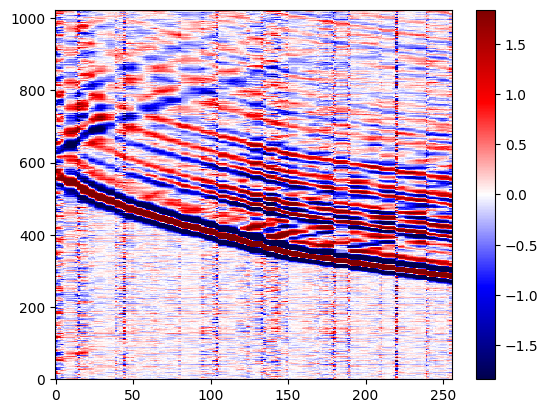

In [16]:
y = ((y - y.mean()) / y.std())[None, None, :, :]
y = torch.from_numpy(y).float()
v = np.percentile(np.abs(y), 95)
plt.imshow(y.squeeze().numpy(), origin='lower', aspect='auto', cmap='seismic', interpolation='none', vmin=-v, vmax=v)

plt.colorbar()
plt.show()

cuda
Epoch 500: total_loss=8.937815e+04
Epoch 1000: total_loss=8.548666e+04
Learning rate is reduced to 0.0008
Epoch 1500: total_loss=8.523870e+04
Epoch 2000: total_loss=8.475751e+04
Epoch 2500: total_loss=8.488333e+04
Learning rate is reduced to 0.00064
Epoch 3000: total_loss=8.392135e+04
Epoch 3500: total_loss=8.435542e+04
Learning rate is reduced to 0.0005120000000000001
Epoch 4000: total_loss=8.411095e+04
Epoch 4500: total_loss=8.423883e+04
Epoch 5000: total_loss=8.394686e+04
Learning rate is reduced to 0.0004096000000000001
Epoch 5500: total_loss=8.580184e+04
Epoch 6000: total_loss=8.370542e+04
Learning rate is reduced to 0.0003276800000000001
Epoch 6500: total_loss=8.390245e+04
Epoch 7000: total_loss=8.409694e+04
Epoch 7500: total_loss=8.405709e+04
Learning rate is reduced to 0.0002621440000000001
Epoch 8000: total_loss=8.416226e+04
Epoch 8500: total_loss=8.393283e+04
Learning rate is reduced to 0.00020971520000000012
Epoch 9000: total_loss=8.385834e+04
Epoch 9500: total_loss=8.4

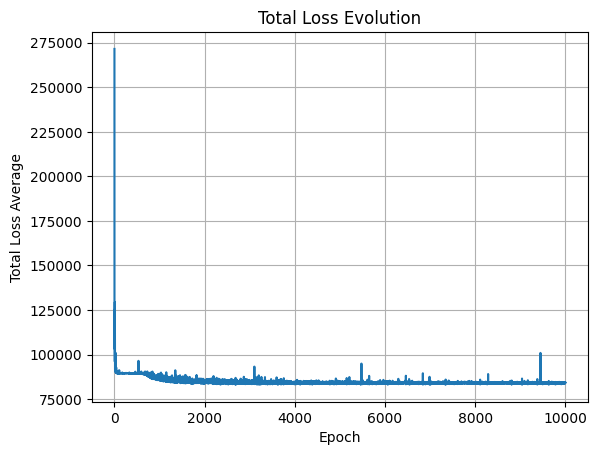

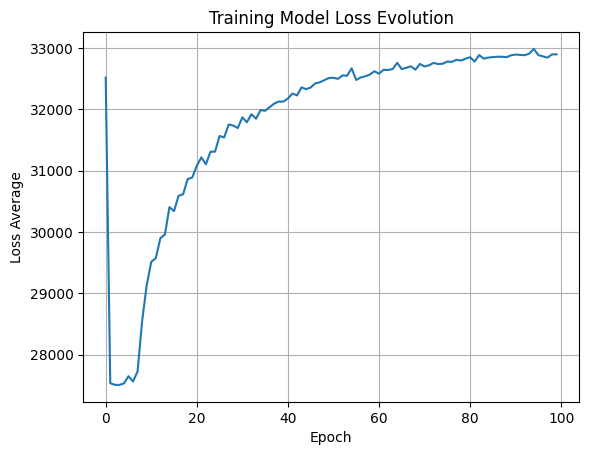

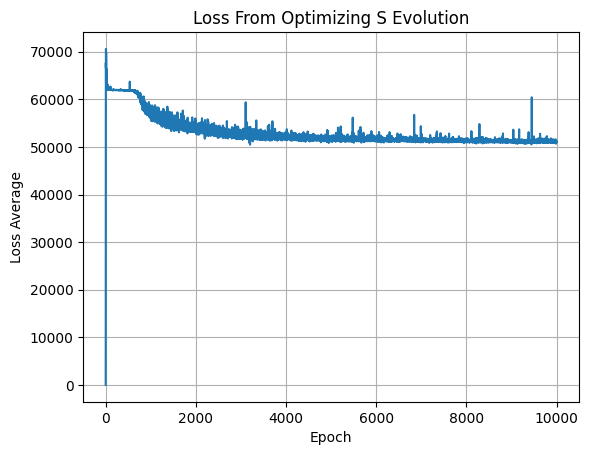

In [17]:
model, S_est, M_est, H_est = train(y,
                                   lr_model=LR_MODEL,
                                   decay=0.8,
                                   g1=1,
                                   g2=1,
                                   n_epoch=N_EPOCH,
                                   it_model=IT_MODEL,
                                   tol=1e-10,
                                   decay_interval=DECAY_INTERVAL,
                                   init_w=0.2)

In [18]:
torch.save(model.state_dict(), f"./Results/SM/{FILE_NAME}/model_DAS_data")
torch.save(M_est, f"./Results/SM/{FILE_NAME}/mask")

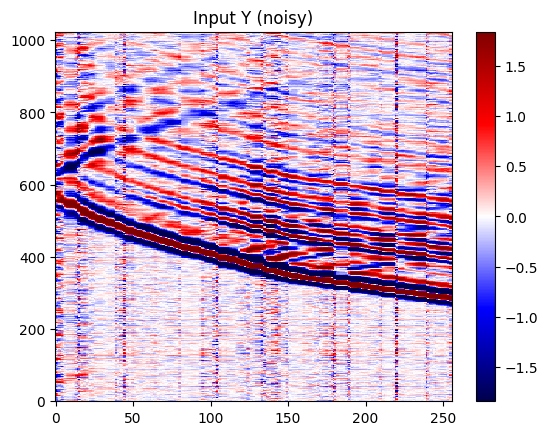

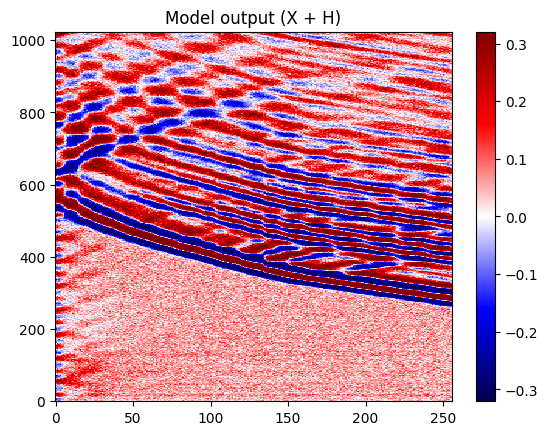

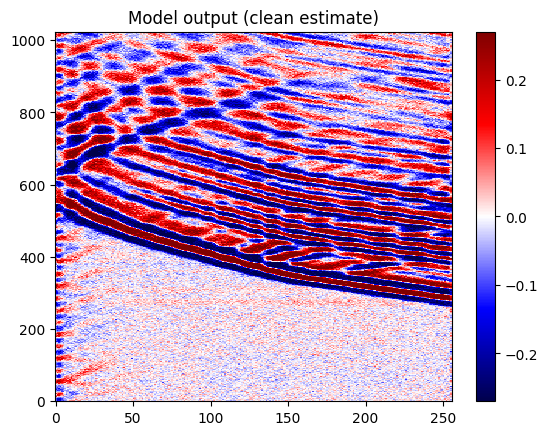

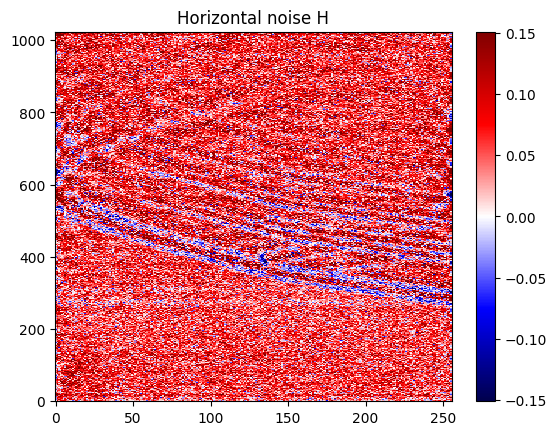

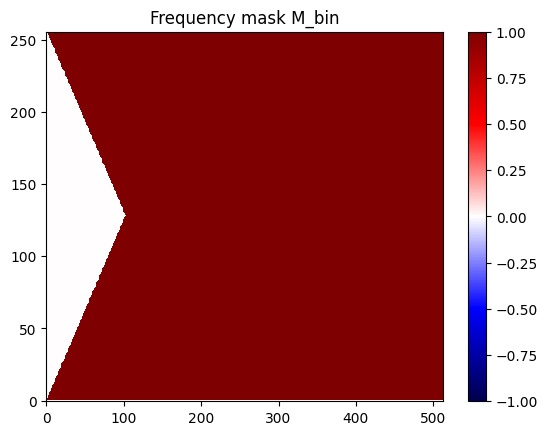

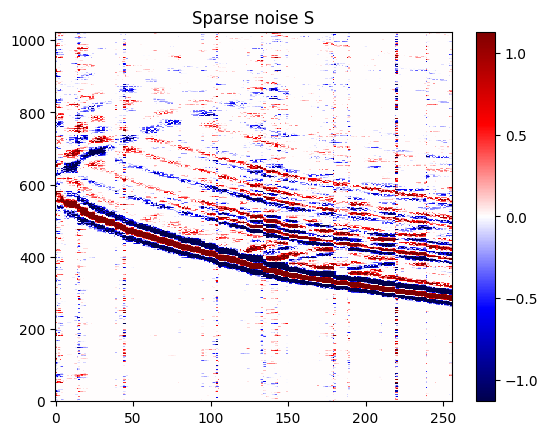

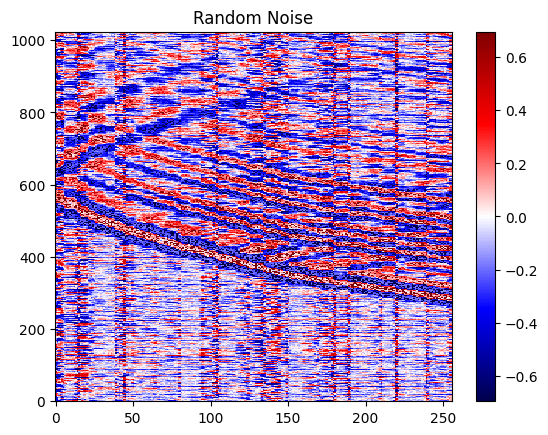

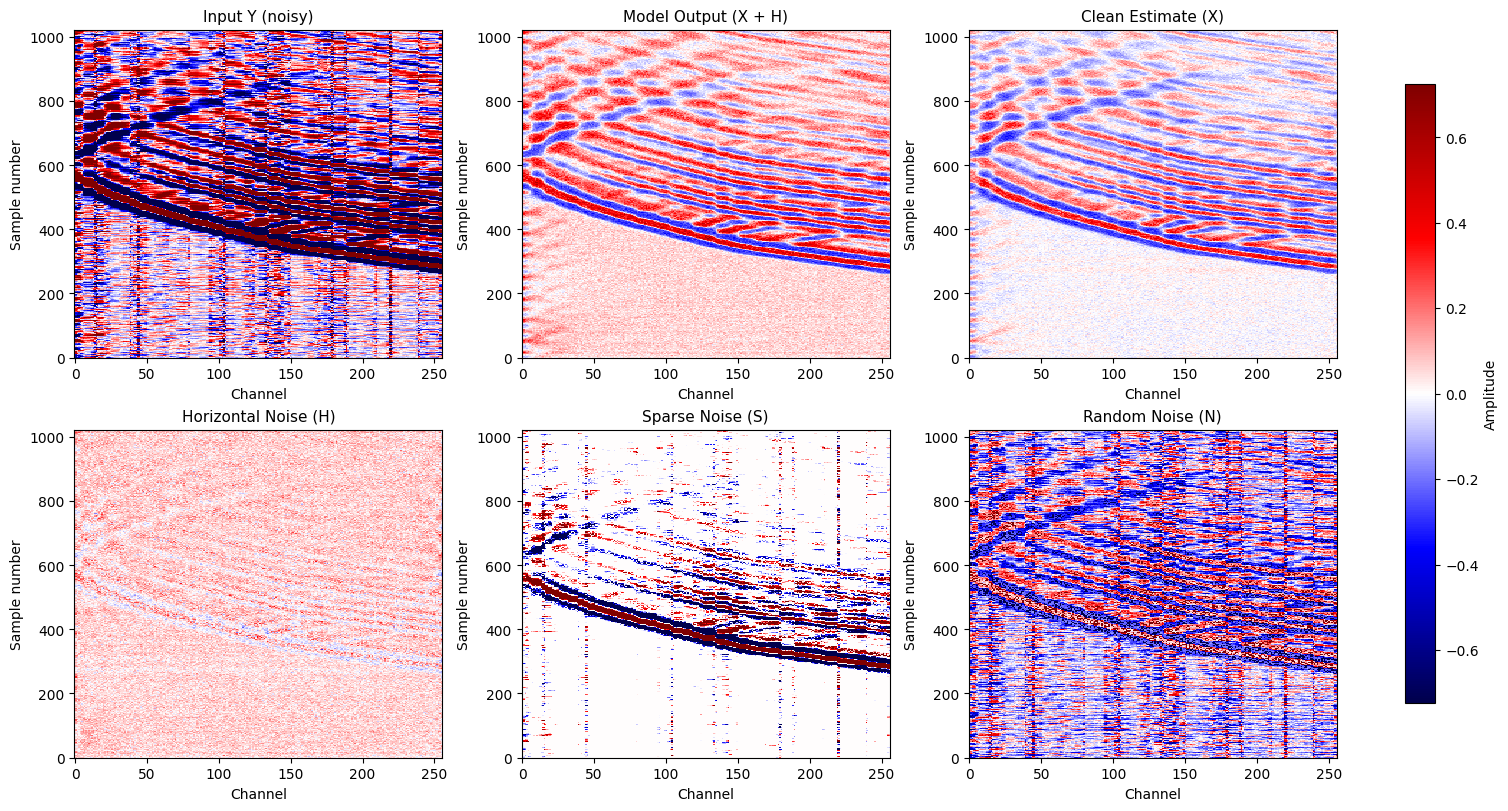

In [19]:
def show_tensor(tensor, title, name):
    t_np = tensor.squeeze().cpu().detach().numpy()
    v = np.percentile(np.abs(t_np), 95)
    plt.imshow(t_np, cmap='seismic', aspect='auto', origin='lower', interpolation='none', vmin=-v, vmax=v)
    plt.colorbar()
    plt.title(title)
    plt.savefig(f'./Results/SM/{FILE_NAME}/{name}.png')
    plt.show()

def show_all_tensors(tensor_dict, file_name, save_name="overview"):

    # Convert tensors → numpy
    data = {}
    for key, tensor in tensor_dict.items():
        t_np = tensor.squeeze().cpu().detach().numpy()
        data[key] = t_np

    # Global symmetric color scaling (robust)
    all_values = np.concatenate([np.abs(v).ravel() for v in data.values()])
    v = np.percentile(all_values, 95)

    n_plots = len(data)
    n_cols = 3
    n_rows = int(np.ceil(n_plots / n_cols))

    fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(15, 4 * n_rows),
        constrained_layout=True
    )

    axes = axes.ravel()

    for ax, (title, img) in zip(axes, data.items()):

        im = ax.imshow(
            img,
            cmap='seismic',
            aspect='auto',
            origin='lower',
            interpolation='none',
            vmin=-v,
            vmax=v
        )

        ax.set_title(title, fontsize=11)
        ax.set_xlabel("Channel")
        ax.set_ylabel("Sample number")

    # Hide unused axes if any
    for ax in axes[len(data):]:
        ax.axis("off")

    # Shared colorbar
    cbar = fig.colorbar(im, ax=axes[:len(data)], shrink=0.85)
    cbar.set_label("Amplitude")

    plt.savefig(f'./Results/SM/{file_name}/{save_name}.png', dpi=300)
    plt.show()
    
device = next(model.parameters()).device
y_device = y.to('cuda')
clean_sig = infer(model, y_device, M_est, 100)
XH = infer(model, y_device, M_est, 100, False)
H_est = XH - clean_sig
N_est = y_device - XH - S_est
show_tensor(y_device, "Input Y (noisy)", f'Y')
show_tensor(XH, "Model output (X + H)", f'XH')
show_tensor(clean_sig, "Model output (clean estimate)", f'X')
show_tensor(H_est, "Horizontal noise H", f'H')
show_tensor(M_est, "Frequency mask M_bin", f'M')
show_tensor(S_est, "Sparse noise S", f'S')
show_tensor(N_est, "Random Noise", f'N')

tensor_dict = {
    "Input Y (noisy)": y_device,
    "Model Output (X + H)": XH,
    "Clean Estimate (X)": clean_sig,
    "Horizontal Noise (H)": H_est,
    "Sparse Noise (S)": S_est,
    "Random Noise (N)": N_est
}
show_all_tensors(tensor_dict, FILE_NAME)

In [20]:
SNR = 10 * torch.log10((torch.norm(clean_sig, p=2)/torch.norm(N_est+H_est+S_est, p=2))).item()
print(SNR)

-8.67368459701538
